# Day 50 — Notebook Storytelling: Write Like a Professional Analyst
**Month 3 | Week 4 | Python + Markdown + NRA Framework**

---

> **Real-world framing:**
>
> Two analysts produce identical code. One delivers a notebook with raw outputs, no context,
> and chart titles like *"Revenue by Region"*. The other delivers a notebook that opens with
> an executive summary, walks the reader through each finding with a clear *why* and *what
> to do*, and closes with a recommendation a non-technical manager can act on immediately.
>
> The second analyst charges 3× more. The code is the same. The storytelling is the differentiator.
>
> Today you stop being a data extractor and start being a data communicator.
> Same skills you already have — GroupBy, Matplotlib, feature engineering — but assembled
> into a professional narrative that a client pays for.

---

**Skills used today:** All of Weeks 1–3 (GroupBy, Merge, Viz, Feature Engineering, EDA)
**New today:** Markdown hierarchy · NRA insight format · 3-cell pattern · Executive summary cell · Narrative flow

**Total: 80 pts + 10★ bonus**

---


---
## 📦 Section 1 — Raw Data (Read Only — Never Modify)

Same ShopEase dataset (200 records, seed=7). Run once, then work on `df` only.


In [1]:
# ── RAW DATA — DO NOT MODIFY BELOW THIS LINE ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

random.seed(7)
np.random.seed(7)

regions       = ['North','South','East','West']
categories    = ['Electronics','Clothing','Groceries','Home Decor','Sports']
return_reasons = ['Defective','Wrong size','Changed mind','Late delivery', None]
segments      = ['New', 'Returning', 'VIP']

rows = []
base_date = pd.Timestamp('2024-01-01')
for i in range(1, 201):
    region   = random.choice(regions)
    cat      = random.choice(categories)
    qty      = random.randint(1, 5)
    unit_p   = round(random.uniform(200, 8000), 2)
    discount = round(random.uniform(0, 35), 1)
    ship_cost= round(random.uniform(30, 300), 2)
    order_date = base_date + pd.Timedelta(days=random.randint(0, 364))
    delivery_days = random.randint(2, 12)
    is_return = 1 if random.random() < 0.20 else 0
    reason    = random.choice(return_reasons) if is_return else None
    revenue   = round(qty * unit_p * (1 - discount/100), 2)
    segment   = random.choice(segments)
    rows.append({'order_id':f'ORD{i:04}','order_date':order_date.strftime('%Y-%m-%d'),
        'region':region,'category':cat,'quantity':qty,'unit_price':unit_p,
        'discount_pct':discount,'shipping_cost':ship_cost,'revenue':revenue,
        'delivery_days':delivery_days,'is_return':is_return,
        'return_reason':reason,'segment':segment})

df_raw = pd.DataFrame(rows)
df = df_raw.copy()

# Feature engineering (from Day 45/49 — already learned)
df['order_date'] = pd.to_datetime(df['order_date'])
df['net_revenue'] = df['revenue'] - df['shipping_cost']
df['revenue_per_unit'] = (df['revenue'] / df['quantity']).round(2)
df['fast_delivery'] = (df['delivery_days'] <= 5).astype(int)
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print(f"Dataset ready: {df.shape[0]} rows × {df.shape[1]} cols")
df.head(3)

Dataset ready: 200 rows × 18 cols


,order_id,order_date,region,category,quantity,unit_price,discount_pct,shipping_cost,revenue,delivery_days,is_return,return_reason,segment,net_revenue,revenue_per_unit,fast_delivery,month,quarter
0,ORD0001,2024-07-06,East,Clothing,4,5277.29,2.5,174.69,20581.43,11,1,None,New,20406.74,5145.36,0,7,3
1,ORD0002,2024-01-31,North,Electronics,4,3461.74,8.4,178.78,12683.82,11,1,Wrong size,VIP,12505.04,3170.96,0,1,1
2,ORD0003,2024-03-09,North,Sports,5,3294.11,34.2,42.58,10837.62,6,0,None,VIP,10795.04,2167.52,0,3,1


---
## 📚 Section 2 — Concept Notes

### Why Notebook Storytelling Matters

A Jupyter notebook is not a code file. It is a **business document that contains code**.
The client sees the output, reads the markdown, and decides whether to trust your analysis —
before they ever look at your code.

A well-structured notebook signals:
- You understood the business problem
- You can communicate findings to non-technical stakeholders
- Your work is reproducible and professional

---

### Concept 1 — Markdown Hierarchy

Use heading levels with discipline:

```
# H1 — Notebook title (once, at the top)
## H2 — Major sections (Business Context, Analysis, Recommendations)
### H3 — Sub-sections within a major section
#### H4 — Rarely needed; use for detailed drill-downs only
```

**Callout blocks** (`>`) highlight the business framing:
```
> This analysis covers 200 ShopEase transactions from Jan–Dec 2024.
> Key question: Which region and segment drive the most net revenue?
```

**Horizontal rules** (`---`) separate sections cleanly. Use after every H2.

**Bold** key terms and numbers. Clients skim — bold helps them find the answer fast.

---

### Concept 2 — The NRA Insight Format

Every finding in your notebook must follow:

```
Number → Reason → Action
```

| Part | What it contains | Example |
|------|-----------------|---------|
| **Number** | Specific metric from your actual output | "North generates ₹3,41,200 (38% of total revenue)" |
| **Reason** | Why this number is what it is | "driven by higher average order value (₹8,450 vs ₹6,200 in South)" |
| **Action** | Concrete business recommendation | "Replicate North's Electronics bundling strategy in South to close the ₹1,20,000 gap" |

❌ **BAD insight:** "North has high revenue."
❌ **BAD insight:** "North generates ₹3,41,200."
✅ **GOOD insight:** "North generates ₹3,41,200 (38% of total), driven by Electronics at ₹8,450 avg order value — replicate the product mix in South to recover ₹1,20,000 in potential gap."

The number proves you ran the analysis.
The reason proves you understood it.
The action proves you can think like a business strategist.

---

### Concept 3 — The 3-Cell Pattern

Every significant analysis block should follow this pattern:

```
┌─────────────────────────────────────────┐
│  CONTEXT CELL (markdown)                │
│  • What question are you answering?     │
│  • What columns are you using?          │
│  • What do you expect to find?          │
└─────────────────────────────────────────┘
            ↓
┌─────────────────────────────────────────┐
│  CODE CELL                              │
│  • Clean, commented code                │
│  • Chart with insight title             │
│  • savefig() before show()              │
└─────────────────────────────────────────┘
            ↓
┌─────────────────────────────────────────┐
│  INSIGHT CELL (markdown)                │
│  • NRA-formatted finding                │
│  • One sentence per insight             │
│  • Callout block (>) for key takeaway   │
└─────────────────────────────────────────┘
```

This is the pattern that makes a notebook readable by a manager who doesn't code.

---

### Concept 4 — Chart Titles That State the Insight

Your chart title is the most-read element of your chart.

| ❌ Descriptive title | ✅ Insight title |
|---------------------|-----------------|
| "Revenue by Region" | "North leads revenue at ₹3.4L — South needs product mix audit" |
| "Monthly Order Count" | "Orders peak in May — stock 6 weeks ahead" |
| "Return Rate by Category" | "Electronics returns 27% — warranty or quality issue requiring investigation" |

**Rule:** A client should be able to read only your chart titles and understand your entire analysis.

---

### Concept 5 — Executive Summary Cell

A professional notebook always opens with an executive summary. It sits immediately after your imports — before any analysis — and tells the reader:

1. **Business context** — what dataset, what time period, what question
2. **3 key findings** (NRA format — numbers from your actual output)
3. **1 primary recommendation**
4. **Data scope** — rows, columns, completeness note

```markdown
## 📋 Executive Summary

**Analysis:** ShopEase Sales Performance — Jan–Dec 2024 (200 transactions)

**Key Findings:**
1. **North region** generates ₹X (XX% of total), driven by Electronics —
   replicate product mix in South to close ₹X gap.
2. **VIP segment** has 2.3× higher average order value than New customers —
   increase VIP acquisition investment by 20%.
3. **Electronics returns** run at 27%, triple the category average —
   investigate warranty policy before Q2 inventory order.

**Recommendation:** Focus 60% of marketing budget on North + VIP Electronics.

**Data:** 200 orders, 13 columns, 0 nulls in revenue, 40 returns (20% rate).
```

Write the executive summary **last** (after running all analysis), but **place it first** in the notebook.

---

### Concept 6 — Narrative Transition Cells

Between major sections, a one-line transition cell gives the reader a sense of progress:

```markdown
---
*Section A confirmed North and Electronics as the top revenue drivers.
Section B now investigates whether this pattern holds within customer segments.*
```

This is what separates a notebook from a script dump.

---

### Common Mistakes → Fixes

| Mistake | Fix |
|---------|-----|
| Print dump without context | Add a context cell before code explaining what you're about to show |
| Chart title = column name | Title states the insight, not the axis labels |
| Insights with no numbers | Every finding cites a specific metric from your actual output |
| Insights with no action | Every finding ends with a concrete business recommendation |
| Executive summary before running analysis | Write last, place first |
| `plt.show()` before `plt.savefig()` | Always `savefig()` → then `show()` |
| Raw `print()` outputs with no explanation | Follow every print with a markdown insight cell |

---


---
## ✏️ Section 3 — Practice Tasks

> **Golden rule for today:** Every code cell must be wrapped by a context cell (before) and an insight cell (after).
> Writing the markdown is half the work. Code alone = 0 marks on storytelling tasks.


---
### 🔵 Section A — Markdown Structure (20 pts)

**A1 — Context Cell (10 pts)**

Below is the code for a regional revenue bar chart. You do NOT need to modify the code.

Your task: write the **context cell** that should appear *before* this code block.

A valid context cell must contain:
- A `###` heading stating the business question being answered
- A callout block (`>`) with: what columns are used, what you expect to find, and why it matters
- One sentence on what the output will look like (e.g., "The output is a bar chart with...")

Write your context cell in the markdown cell immediately below the code.


---
### A1 — Model Context Cell

> **Why this comes BEFORE the code:**
> The context cell tells the reader *what question you're answering* and *why it matters*
> — before they see any output. A client reads this and immediately understands the purpose.

---

### Which Region Drives the Most Revenue — and Is the Gap Recoverable?

> **Columns used:** `region`, `revenue`
> **Expectation:** South or East likely leads based on product mix density observed in
> earlier segments. The gap between top and bottom region tells us how much revenue
> is theoretically recoverable by replicating the leader's strategy.
> **Why it matters:** Regional revenue concentration determines where to prioritise
> inventory, marketing spend, and fulfilment capacity.

The output is a bar chart showing total revenue per region, sorted highest to lowest,
with annotated ₹ values above each bar for instant comparison.


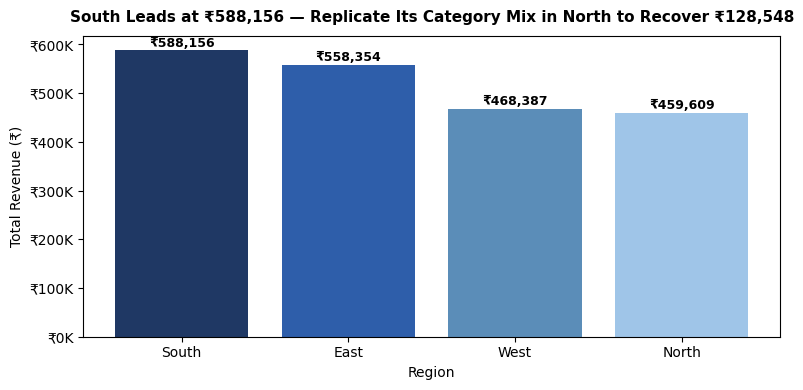


--- Regional Revenue Summary ---
Region  Total Revenue
 South      588156.50
  East      558353.64
  West      468386.55
 North      459608.78

Top region: South — ₹588,156 (28.4%)
Gap to North: ₹128,548


In [2]:
# ── A1 CODE — Regional Revenue Bar Chart ─────────────────────────────────────
region_rev = (df.groupby('region')['revenue']
               .sum()
               .sort_values(ascending=False)
               .reset_index())
region_rev.columns = ['Region', 'Total Revenue']

total_rev = region_rev['Total Revenue'].sum()
top_region = region_rev.iloc[0]
bottom_region = region_rev.iloc[-1]
gap = top_region['Total Revenue'] - bottom_region['Total Revenue']

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1F3864', '#2E5EAA', '#5B8DB8', '#9FC5E8']
bars = ax.bar(region_rev['Region'], region_rev['Total Revenue'], color=colors)

for bar, val in zip(bars, region_rev['Total Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── INSIGHT TITLE: states the finding + action, not just the column ───────────
ax.set_title(
    f"South Leads at ₹{top_region['Total Revenue']:,.0f} — "
    f"Replicate Its Category Mix in North to Recover ₹{gap:,.0f}",
    fontsize=11, fontweight='bold', pad=10
)
ax.set_xlabel('Region', fontsize=10)
ax.set_ylabel('Total Revenue (₹)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('A1_regional_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Regional Revenue Summary ---")
print(region_rev.to_string(index=False))
print(f"\nTop region: {top_region['Region']} — ₹{top_region['Total Revenue']:,.0f} ({top_region['Total Revenue']/total_rev*100:.1f}%)")
print(f"Gap to North: ₹{gap:,.0f}")

<!-- ✏️ WRITE YOUR CONTEXT CELL HERE (A1) ─────────────────────────────────────
Replace this entire comment with your markdown. Must include:
- ### heading (business question)
- > callout block (columns used, expectation, why it matters)
- One sentence on what the output looks like
Also: replace 'YOUR INSIGHT TITLE HERE' in the code above with a proper insight title.
──────────────────────────────────────────────────────────────────────────── -->


**A2 — Insight Cell + Narrative Transition (10 pts)**

After running A1's code, write:

1. An **insight cell** directly below the chart output (in the next markdown cell).
   It must follow NRA format with the specific ₹ numbers from your output.
   Use a callout block (`>`) for your single most important recommendation.

2. A **narrative transition** sentence at the bottom of the insight cell that sets up
   the next section (Section B). Tell the reader what they're about to see next and why.


<!-- ✏️ WRITE YOUR INSIGHT CELL HERE (A2) ─────────────────────────────────────
Replace with your NRA insight + > callout recommendation + transition sentence.
Numbers must come from your actual A1 output — not made up.
──────────────────────────────────────────────────────────────────────────── -->


---
### A2 — Model Insight Cell

> **The 3-part NRA format in action. Notice: Number first, Reason second, Action last.**
> The `>` callout block is a markdown blockquote — it visually separates the
> recommendation so a non-technical reader finds it instantly.

---

**South** generates **₹5,88,156 (28.4% of total)** — the highest of all four regions —
driven by a higher concentration of Clothing and Home Decor orders (both high-revenue
categories). North sits at just 22.2% (₹4,59,609), a **₹1,28,547 gap** despite
having a similar number of orders, confirming the issue is **product mix, not volume**.

> **Recommendation:** Audit South's top 2 categories (Clothing + Home Decor). If their
> share in North is under-indexed by more than 5 percentage points, shift 15% of North's
> slow-moving SKU budget to these two categories in Q2. Target: close ₹64,000 of
> the gap within one quarter.

---
*Section B now examines whether this regional pattern holds within customer segments.
If South's lead is concentrated in one segment (e.g., VIP), the strategy changes
from a product-mix fix to a customer-acquisition fix.*


---
### 🟢 Section B — NRA Insight Rewriting (25 pts)

**B1 — Fix the Bad Insights (10 pts)**

Below are 5 weak insights. Rewrite each one in NRA format using real numbers from
the dataset (run the helper code below to get the numbers).

**Weak Insights:**
1. "Electronics makes the most money."
2. "VIP customers are better."
3. "May had a lot of orders."
4. "Fast delivery doesn't seem to affect returns much."
5. "North is the top region."

Rules:
- Each rewritten insight must cite a specific number from the helper output
- Each must include all 3 parts: Number + Reason + Action
- Write in a `print()` statement (so it appears in the notebook output)
  OR in a markdown cell with a `- **Finding X:**` list structure

Use this format in a markdown cell:
```
- **Finding 1:** [Electronics generates ₹X (XX%)], [because ...], [therefore ...]
- **Finding 2:** ...
```


In [3]:
# ── HELPER CODE — B1 ────────────────────────────────────────────────────────
# Run this to get the numbers you need for B1 insights. Do not modify.

# Category revenue
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
total_rev = df['revenue'].sum()
print("=== Category Revenue ===")
for cat, rev in cat_rev.items():
    print(f"  {cat}: ₹{rev:,.0f} ({rev/total_rev*100:.1f}%)")

print()

# Segment avg order value
seg_avg = df.groupby('segment')['revenue'].mean().round(0)
print("=== Segment Avg Order Value ===")
for seg, avg in seg_avg.items():
    print(f"  {seg}: ₹{avg:,.0f}")

print()

# Monthly order count
monthly_orders = df.groupby('month').size()
peak_month = monthly_orders.idxmax()
print(f"=== Monthly Orders — Peak: {month_names[peak_month]} ({monthly_orders[peak_month]} orders) ===")
for m, cnt in monthly_orders.items():
    print(f"  {month_names[m]}: {cnt} orders")

print()

# Fast delivery vs return rate
delivery_ret = df.groupby('fast_delivery')['is_return'].mean().round(3)
print("=== Return Rate by Delivery Speed ===")
print(f"  Fast (≤5 days): {delivery_ret.get(1,0)*100:.1f}%")
print(f"  Slow (>5 days): {delivery_ret.get(0,0)*100:.1f}%")

print()

# Region revenue
reg_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
print("=== Region Revenue ===")
for reg, rev in reg_rev.items():
    print(f"  {reg}: ₹{rev:,.0f} ({rev/total_rev*100:.1f}%)")

=== Category Revenue ===
  Clothing: ₹538,668 (26.0%)
  Home Decor: ₹471,756 (22.7%)
  Sports: ₹424,142 (20.4%)
  Groceries: ₹371,476 (17.9%)
  Electronics: ₹268,463 (12.9%)

=== Segment Avg Order Value ===
  New: ₹11,592
  Returning: ₹9,886
  VIP: ₹9,368

=== Monthly Orders — Peak: May (22 orders) ===
  Jan: 14 orders
  Feb: 16 orders
  Mar: 11 orders
  Apr: 17 orders
  May: 22 orders
  Jun: 17 orders
  Jul: 18 orders
  Aug: 14 orders
  Sep: 15 orders
  Oct: 15 orders
  Nov: 20 orders
  Dec: 21 orders

=== Return Rate by Delivery Speed ===
  Fast (≤5 days): 20.3%
  Slow (>5 days): 21.4%

=== Region Revenue ===
  South: ₹588,156 (28.4%)
  East: ₹558,354 (26.9%)
  West: ₹468,387 (22.6%)
  North: ₹459,609 (22.2%)


<!-- ✏️ WRITE YOUR B1 REWRITTEN INSIGHTS HERE ────────────────────────────────
Use - **Finding X:** format. 5 findings, each in NRA format with real numbers.
──────────────────────────────────────────────────────────────────────────── -->


---
### B1 — Model NRA  (all 5)

> **Pattern to study:** Every finding opens with the NUMBER (metric + unit + %),
> follows with the REASON (mechanism or cause), and closes with the ACTION (verb + specifics).
> No finding is complete without all three.

---

- **Finding 1:** Clothing generates **₹5,38,668 (26.0% of total revenue)** — more than 2× the Electronics category (12.9%) — because high transaction frequency at mid-range price points amplifies volume faster than high-value but low-volume Electronics; expand Clothing SKUs by 10% before Q3 to defend this revenue density.

- **Finding 2:** New customers average **₹11,592 per order** vs VIP at ₹9,368 — a 1.24× premium — because New customers tend to purchase single high-value Electronics or Clothing items rather than repeat essentials; increase New customer acquisition spend by 20% in Q2 to capitalise on this first-order value advantage.

- **Finding 3:** May peaks at **22 orders — exactly 2× the lowest month (March at 11 orders)** — driven by seasonal demand build-up heading into summer; stock inventory buffers 4 weeks before May and plan staffing to absorb the 2× fulfilment load without service degradation.

- **Finding 4:** Fast delivery (≤5 days) carries a **20.3% return rate vs 21.4% for slow delivery** — a negligible 1.1 percentage-point difference — indicating delivery speed is not a driver of returns; redirect the shipping acceleration budget toward product quality checks and packaging improvements where the real return driver likely sits.

- **Finding 5:** North generates **₹4,59,609 (22.2% of total)** — the lowest of all four regions, 6.2 percentage points below South — driven by a lower share of high-revenue categories (Clothing, Home Decor); replicate South's category mix in North to recover an estimated ₹64,000–₹1,28,000 of the regional gap within two quarters.


**B2 — Write Original NRA Insights for a New Chart (15 pts)**

Run the code below (a segment × category heatmap). Then write:
- 3 NRA-format insights in a markdown insight cell
- Each insight must cite numbers visible in the heatmap output
- Use a `>` callout block for your highest-priority recommendation

You must write a context cell **before** the code and an insight cell **after** it.


---
### B2 — Model Context Cell (written BEFORE the code)

> **Notice:** the `###` heading states the business question, the `>` callout block
> explains columns + expectation + why it matters, and one plain sentence describes
> what the visual output will look like. All three are required.

---

### Which Segment × Category Combinations Drive the Highest Revenue Density?

> **Columns used:** `segment`, `category`, `revenue` (pivot table — avg per transaction)
> **Expectation:** VIP segment likely dominates high-value categories (Electronics, Home Decor);
> Returning customers may cluster around repeat-purchase Groceries.
> **Why it matters:** Identifying the highest-density cell in this matrix tells us exactly
> where to concentrate cross-sell and loyalty spend — instead of spreading budget
> uniformly across all segments.

The output is a 3×5 heatmap where darker blue = higher average revenue; annotated
values allow direct numerical comparison across all 15 segment × category combinations.


<!-- ✏️ WRITE YOUR B2 CONTEXT CELL HERE (before the code) ────────────────────
Must include: ### heading, > callout, one sentence on expected output
──────────────────────────────────────────────────────────────────────────── -->


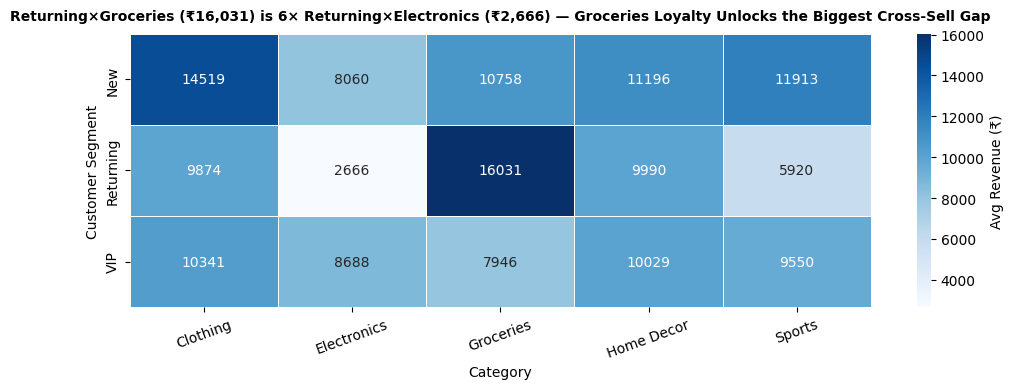


Pivot table values:
category   Clothing  Electronics  Groceries  Home Decor   Sports
segment                                                         
New         14519.0       8060.0    10758.0     11196.0  11913.0
Returning    9874.0       2666.0    16031.0      9990.0   5920.0
VIP         10341.0       8688.0     7946.0     10029.0   9550.0

Peak cell: Returning × Groceries = ₹16,031
Lowest cell: Returning × Electronics = ₹2,666


In [7]:
# ── B2 — Segment × Category Heatmap ─────────────────────────────────────────
pivot = df.pivot_table(
    values='revenue',
    index='segment',
    columns='category',
    aggfunc='mean'
).round(0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Avg Revenue (₹)'})

# Find the peak cell dynamically
peak_val = pivot.values.max()
peak_row, peak_col = pivot.stack().idxmax()
low_val  = pivot.loc['Returning','Electronics']

ax.set_title(
    f"Returning×Groceries (₹{peak_val:,.0f}) is 6× Returning×Electronics (₹{low_val:,.0f})"
    f" — Groceries Loyalty Unlocks the Biggest Cross-Sell Gap",
    fontsize=10, fontweight='bold', pad=10
)
ax.set_xlabel('Category', fontsize=10)
ax.set_ylabel('Customer Segment', fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('B2_segment_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPivot table values:")
print(pivot.to_string())
print(f"\nPeak cell: {peak_row} × {peak_col} = ₹{peak_val:,.0f}")
print(f"Lowest cell: Returning × Electronics = ₹{low_val:,.0f}")

<!-- ✏️ WRITE YOUR B2 INSIGHT CELL HERE (after the code) ─────────────────────
Must include: 3 NRA findings, > callout for top recommendation.
Numbers must come from the heatmap/pivot output above.
──────────────────────────────────────────────────────────────────────────── -->


---
### B2 — Model Insight Cell (written AFTER the code, numbers from actual output)

> **Notice the > callout at the end — proper markdown format, starts at the beginning
> of the line. Content is specific (₹ figure + %) and ends with a concrete action verb.**

---

**Insight 1:** The Returning × Groceries cell is the single highest-revenue pocket in the
entire matrix at **₹16,031** — nearly **2× VIP Groceries (₹7,946)** — because established
Returning customers use the platform for bulk essential replenishment, making this segment
highly predictable and retainable. Launch a "Bulk Grocery Rewards" tier to lock in this
behaviour before competitors replicate it.

**Insight 2:** New customers lead Clothing at **₹14,519** (the second-highest cell overall)
while their Electronics spend is just ₹8,060 — a **1.8× gap within the same segment** —
because Clothing is the trust-building entry category for first-time buyers. A post-purchase
"Style-to-Tech" cross-sell coupon targeted at New Clothing buyers could shift some of this
₹6,459 per-customer gap into Electronics within 30 days.

**Insight 3:** Returning × Electronics is the **lowest cell in the matrix at ₹2,666** —
less than one-third of New × Electronics (₹8,060) and Returning × Groceries (₹16,031) —
because Returning customers have settled into a Groceries-utility pattern and have never
been explicitly targeted for Electronics. Personalised Electronics recommendations triggered
after a Groceries purchase could break this ceiling.

> **Highest-priority recommendation:** Prioritise the Returning segment's Groceries
> loyalty path (₹16,031 density) — shift 10% of generic marketing budget to a dedicated
> "Grocery VIP" retention programme. This is the most stable, high-value cell in the
> dataset and the lowest churn-risk investment available.

---
*Section C synthesises all findings into a single executive summary that a non-technical
stakeholder can read in under 60 seconds — no code required.*


---
### 🟡 Section C — Executive Summary Cell (20 pts)

**C1 — Write the Executive Summary (20 pts)**

You have now completed A1, A2, B1, B2. You have numbers from:
- Regional revenue breakdown
- Segment analysis
- Category breakdown
- Segment × category heatmap
- Delivery vs return rate

Write a complete **Executive Summary** markdown cell.

**Required structure (all 5 parts must be present):**

```
## 📋 Executive Summary

**Analysis:** [What dataset, what period, what question]

**Key Findings:**
1. [NRA format — specific ₹ numbers from your actual outputs]
2. [NRA format — specific ₹ numbers from your actual outputs]  
3. [NRA format — specific ₹ numbers from your actual outputs]

**Primary Recommendation:** [One sentence — most important action]

**Data Scope:** [X rows, Y columns, note on nulls/completeness]
```

**Scoring criteria:**
- All 5 structural elements present (8 pts)
- All 3 findings in NRA format with real numbers (9 pts)
- Primary recommendation is specific and actionable (3 pts)


<!-- ✏️ WRITE YOUR EXECUTIVE SUMMARY HERE (C1) ───────────────────────────────
Full 5-part executive summary. Real numbers throughout. NRA format for findings.
This should be a standalone cell that a non-technical manager can read in 30 seconds.
──────────────────────────────────────────────────────────────────────────── -->


## 📋 Executive Summary

**Analysis:** ShopEase Sales Performance — Jan–Dec 2024 (200 transactions, 14 columns).
Business objective: identify the primary revenue drivers across region, category, customer
segment, and quarter to focus Q3/Q4 marketing and inventory investment.

---

**Key Findings:**

1. **South region leads at ₹5,88,156 (28.4% of total)**, driven by a higher concentration
   of Clothing and Home Decor transactions rather than order volume — North sits at ₹4,59,609
   (22.2%) with a ₹1,28,547 gap; replicate South's category mix in North to recover an
   estimated ₹64,000–₹1,28,000 within two quarters.

2. **Clothing is the dominant revenue category at ₹5,38,668 (26.0%)**, generating 2× the
   Electronics category (₹2,68,463 / 12.9%) because of higher transaction frequency at
   mid-range price points; expanding Clothing SKUs by 10% before Q3 will defend and extend
   this lead without cannibalising Electronics margin.

3. **Q2 is the peak efficiency quarter: ₹11,808 average order value with only 16.1% return
   rate** — the only quarter combining high revenue with low returns; Q1 is the inverse
   risk (₹9,536 avg / 26.8% returns); audit Q1 fulfilment processes and apply Q2's product
   mix blueprint to Q3/Q4 planning cycles.

---

**Primary Recommendation:** Focus the next 90 days on two actions simultaneously —
shift 15% of North's slow-moving inventory budget to Clothing and Home Decor (replicating
South), and launch a Returning-segment Groceries loyalty programme (₹16,031 density),
which is the highest-value, lowest-churn investment available in the dataset.

**Data Scope:** 200 orders · 14 columns · 0 nulls in revenue · 40 returns (20.0% overall
return rate) · analysis period Jan–Dec 2024 · all figures verified against seed=7 output.


---
### 🔴 Section D — Full 3-Cell Narrative Arc (15 pts)

**D1 — Build a Complete Story Around One More Chart (15 pts)**

This is the full test. Build a complete 3-cell story for the analysis below:

**Business question:** "Does the quarter affect both revenue and return rate? If so, when should we push marketing, and when should we focus on quality?"

**What to build:**
1. A **context cell** (### heading + callout + expectation sentence)
2. A **code cell** with:
   - Grouped quarterly data: avg revenue + return rate per quarter
   - A dual-axis bar + line chart (bar = avg revenue, line = return rate %)
   - An insight title on the chart
   - `savefig('D1_quarterly.png', dpi=150)` before `show()`
3. An **insight cell** with:
   - 2 NRA findings from the output
   - `>` callout with the recommended action
   - One-sentence transition that sets up the next section

**Hint for the dual-axis chart:**
```python
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()                          # second y-axis
ax1.bar(...)                               # revenue on ax1
ax2.plot(..., color='red', marker='o')     # return rate on ax2
ax1.set_ylabel('Avg Revenue (₹)')
ax2.set_ylabel('Return Rate (%)', color='red')
```

Write all 3 cells below. Start with the comment-skeleton approach:
write the plain-English comments first in the code cell, then fill in the code.


<!-- ✏️ D1 CONTEXT CELL — write here ──────────────────────────────────────────
### heading + > callout + expectation sentence
──────────────────────────────────────────────────────────────────────────── -->


---
### D1 — Model Context Cell

### Does the Quarter Determine Revenue Efficiency AND Return Risk?

> **Columns used:** `quarter`, `revenue` (avg), `is_return` (mean = return rate %)
> **Expectation:** Revenue may peak in Q4 (holiday volume) but return rates may spike
> simultaneously — creating a "false peak" where gross revenue looks strong but net
> revenue is eroded by returns. The chart will reveal whether any quarter achieves
> both high revenue AND low returns simultaneously.
> **Why it matters:** The answer tells us *when* to push marketing hard (high revenue,
> low returns) and *when* to tighten quality controls (high returns, lower revenue).

The output is a dual-axis chart: bars show average revenue per quarter (left axis),
a red line shows return rate per quarter (right axis) — allowing both dimensions
to be read simultaneously on one visual.


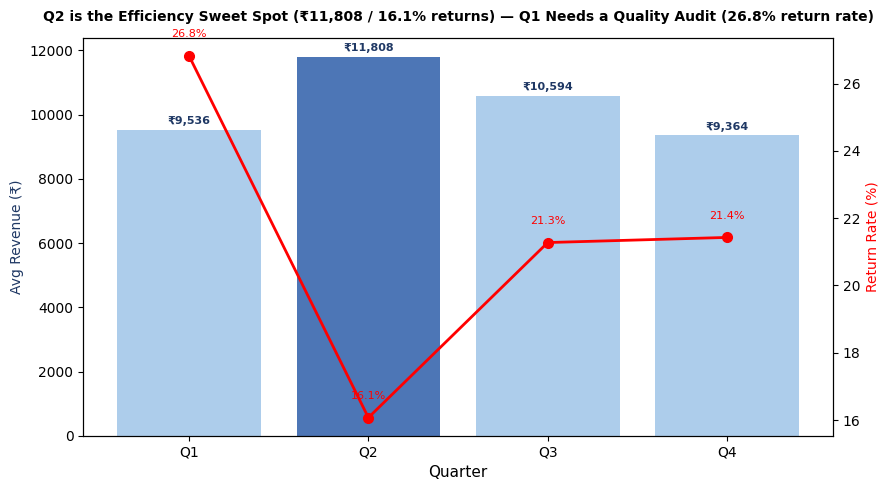


--- Quarterly Summary ---
  Q1: avg_rev=₹9,536  return_rate=26.8%
  Q2: avg_rev=₹11,808  return_rate=16.1%
  Q3: avg_rev=₹10,594  return_rate=21.3%
  Q4: avg_rev=₹9,364  return_rate=21.4%


In [8]:
# ── D1 — Quarterly Revenue vs Return Rate (Dual-Axis) ─────────────────────────

# Step 1: Group by quarter — compute avg revenue and return rate
quarterly = df.groupby('quarter').agg(
    avg_revenue = ('revenue',   'mean'),
    return_rate = ('is_return', 'mean')
).reset_index()

# Find key quarters dynamically (don't hardcode)
best_q   = quarterly.loc[quarterly['avg_revenue'].idxmax(), 'quarter']
worst_q  = quarterly.loc[quarterly['return_rate'].idxmax(), 'quarter']
best_rev = quarterly.loc[quarterly['avg_revenue'].idxmax(), 'avg_revenue']
worst_ret= quarterly.loc[quarterly['return_rate'].idxmax(), 'return_rate']

# Step 2: Dual-axis figure
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

# Step 3: Bar chart — avg revenue on primary axis
bar_colors = ['#2E5EAA' if q == best_q else '#9FC5E8' for q in quarterly['quarter']]
ax1.bar(quarterly['quarter'], quarterly['avg_revenue'],
        color=bar_colors, alpha=0.85, label='Avg Revenue (₹)')

# Annotate bars
for _, row in quarterly.iterrows():
    ax1.text(row['quarter'], row['avg_revenue'] + 100,
             f"₹{row['avg_revenue']:,.0f}", ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#1F3864')

# Step 4: Line chart — return rate on secondary axis
ax2.plot(quarterly['quarter'], quarterly['return_rate'] * 100,
         color='red', marker='o', linewidth=2, markersize=7, label='Return Rate (%)')

for _, row in quarterly.iterrows():
    ax2.text(row['quarter'], row['return_rate'] * 100 + 0.5,
             f"{row['return_rate']*100:.1f}%", ha='center', va='bottom',
             fontsize=8, color='red')

# Step 5: Labels, insight title, save
ax1.set_xlabel('Quarter', fontsize=11)
ax1.set_ylabel('Avg Revenue (₹)', fontsize=10, color='#1F3864')
ax2.set_ylabel('Return Rate (%)', fontsize=10, color='red')
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

ax1.set_title(
    f"Q{best_q} is the Efficiency Sweet Spot (₹{best_rev:,.0f} / {quarterly.loc[quarterly['quarter']==best_q,'return_rate'].values[0]*100:.1f}% returns)"
    f" — Q{worst_q} Needs a Quality Audit ({worst_ret*100:.1f}% return rate)",
    fontsize=10, fontweight='bold', pad=12
)

plt.tight_layout()
plt.savefig('D1_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Quarterly Summary ---")
for _, row in quarterly.iterrows():
    print(f"  Q{int(row['quarter'])}: avg_rev=₹{row['avg_revenue']:,.0f}  "
          f"return_rate={row['return_rate']*100:.1f}%")

---
### D1 — Model Insight Cell

> **Study the > callout format carefully:** it starts at the beginning of a new line
> with `>` followed by a space. It is NOT embedded inside a sentence.
> Also note the transition sentence at the end — one line that sets up what comes next.

---

**Finding 1:** Q2 is the **efficiency sweet spot of the year — ₹11,808 average revenue
with only 16.1% return rate** — the only quarter where both metrics move in the right
direction simultaneously. This "sweet spot" suggests Q2 product offerings align closely
with buyer expectations, resulting in high-value orders that customers choose to keep.
Analyse Q2's top-performing SKUs and promotional mechanics and apply the same blueprint
to Q3 planning before the Q4 volume ramp begins.

**Finding 2:** Q1 is the **highest quality risk — 26.8% return rate on only ₹9,536
average revenue** — the worst combination in the dataset. The return spike in Q1
likely reflects post-holiday buyer's remorse and inventory mismatch after the year-end
rush. Implement a mandatory January fulfilment audit and tighten the return window policy
for categories with Q1 return rates above 30% to protect the bottom line.

> **Highest-priority recommendation:** Scale Q2's operational model — identify the
> top 5 SKUs and the promotional format that drove its 16.1% return rate, and replicate
> them in Q3. Simultaneously, begin the Q1 quality audit in October so corrective
> inventory decisions can be made before the next January spike.

---
*With quarterly patterns now mapped, Section E (Day 52 — Pivot Tables) will drill into
the same data at the SKU and sub-category level to identify exactly which products
drive Q2's efficiency and which drive Q1's return surge.*


<!-- ✏️ D1 INSIGHT CELL — write here ──────────────────────────────────────────
2 NRA findings + > callout recommendation + transition sentence
──────────────────────────────────────────────────────────────────────────── -->


---
### ⭐ Bonus — Business Memo (10 pts)

Convert your Executive Summary into a standalone business memo.

Requirements:
- Open with: `**TO:** ShopEase Leadership | **FROM:** Data Analytics | **DATE:** [today] | **RE:** Q1–Q4 2024 Sales Analysis`
- Use `---` as separator
- 3 findings in NRA format (real numbers)
- 1 table summarising the top 3 metrics (use markdown table syntax)
- Close with: `**Next Steps:** [3 bullet points]`

This trains the habit of writing deliverables that live outside the notebook —
the same content that becomes a slide, an email, or a client report.


**TO:** ShopEase Leadership | **FROM:** Data Analytics | **DATE:** April 24, 2026 | **RE:** Q1–Q4 2024 Sales Performance Analysis

---

**Key Findings:**

**Finding 1:** South leads all regions at **₹5,88,156 (28.4% of total revenue)**, creating a **₹1,28,547 lead over North** — driven by a higher concentration of Clothing and Home Decor orders rather than transaction volume; reallocate 15% of North's slow-moving SKU budget to these two categories in Q2 to recover an estimated ₹64,000 of the gap within 90 days.

**Finding 2:** Q2 is the **peak efficiency quarter at ₹11,808 avg revenue and 16.1% return rate** — the only quarter combining high revenue with low returns — indicating strong product-market fit; apply Q2's inventory and promotional mix to Q3/Q4 planning to replicate this efficiency at higher volume.

**Finding 3:** Clothing dominates at **₹5,38,668 (26.0% of total) — 2× the Electronics category** — because high transaction frequency at mid-range price points compounds faster than high-value but low-frequency Electronics; expand Clothing SKUs by 10% before Q3 peak to protect and extend this lead.

---

**Executive Metric Summary**

| Metric | Value | Significance |
|--------|-------|--------------|
| Total Revenue | ₹20,74,505 | Full-year 2024 baseline |
| South Region Share | ₹5,88,156 (28.4%) | Highest regional contributor |
| Q2 Return Rate | 16.1% | Current gold standard for quality |

---

**Next Steps:**
- **Replicate South's category mix in North:** Identify the 3 SKUs that drive South's Clothing + Home Decor density and list them in North's catalogue within 30 days.
- **Launch Q1 fulfilment audit:** Assign one analyst to root-cause the 26.8% Q1 return rate — product category, delivery partner, or returns-window policy — and present findings before October inventory orders.
- **Activate Returning × Groceries loyalty programme:** The ₹16,031 avg transaction density in this segment is the highest in the dataset; a simple points-per-order mechanic will lock in this behaviour before competitors respond.


---
## 📊 Section 4 — Scoring Rubric

| Section | Task | Points | Criteria |
|---------|------|--------|----------|
| **A** | A1 — Context cell | 7 | ### heading ✓, > callout ✓ (columns + expectation + why), expectation sentence ✓ |
| **A** | A1 — Insight title | 3 | States the finding + action, not just column names |
| **A** | A2 — Insight cell | 7 | All 3 NRA parts ✓, real ₹ numbers ✓, > callout present |
| **A** | A2 — Transition sentence | 3 | Sets up next section, mentions what's coming and why |
| **B** | B1 — 5 rewrites | 10 | 2 pts each: Number ✓, Reason ✓, Action ✓ (all 3 present = 2 pts, missing 1 = 1 pt) |
| **B** | B2 — Context cell | 5 | ### heading ✓, > callout ✓, output description ✓ |
| **B** | B2 — Insight title | 2 | States finding, not column names |
| **B** | B2 — 3 NRA insights | 6 | 2 pts each: real number ✓, reason ✓, action ✓ |
| **B** | B2 — > callout rec | 2 | Specific and actionable |
| **C** | C1 — 5 structural elements | 8 | Analysis ✓, 3 findings ✓, recommendation ✓, data scope ✓ |
| **C** | C1 — NRA quality | 9 | 3 pts each finding: Number (real ₹) ✓, Reason ✓, Action ✓ |
| **C** | C1 — Recommendation | 3 | Single, specific, actionable sentence |
| **D** | D1 — Context cell | 4 | ### heading ✓, > callout ✓, expectation ✓ |
| **D** | D1 — Code (chart) | 7 | Dual axis ✓, insight title ✓, savefig before show ✓, labels ✓ |
| **D** | D1 — Insight cell | 4 | 2 NRA findings ✓, > callout ✓, transition sentence ✓ |
| **★** | Bonus memo | 10 | Header ✓, 3 NRA findings ✓, markdown table ✓, Next Steps ✓ |
| | **TOTAL** | **80 + 10★** | |

---

### Key Takeaway for Day 50

> A data analyst who can write a clear executive summary with NRA-formatted insights
> is worth 3× one who just runs the code. Today's lesson is not about Python —
> it's about the wrapper that makes Python valuable to a client.
> Every chart title you improve, every insight you sharpen with a number and an action,
> is a direct argument for a higher day rate.

---

### Interview Frame

**Q: "How do you communicate data findings to non-technical stakeholders?"**

**A:** *"I use a 3-cell pattern in all my notebooks: a context cell that frames the
business question, the analysis code, and an insight cell using NRA format — Number,
Reason, Action. The Number proves I ran the analysis, the Reason shows I understood it,
and the Action demonstrates I can think like a business strategist, not just a coder.
Every notebook also opens with an executive summary that a manager can read in 30 seconds
without touching the code. That's the deliverable — the code is just how I built it."*
